# Matriz de Confusion
En una matriz de confusion se considera los valores de predicción para las clases de un algoritmo con los valores de una clase de valores reales hechos en la medición.

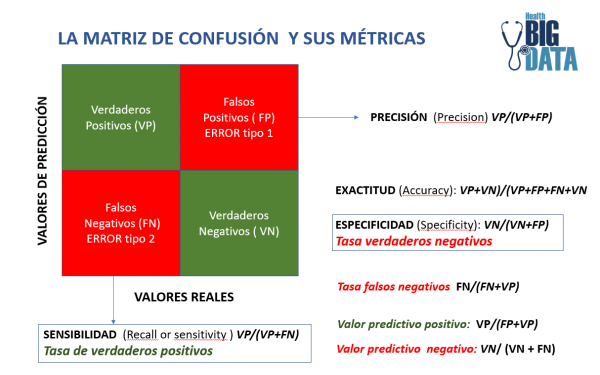

Accuracy (exactitud) no es la unica métrica. Revisa un comportamiento globalb de las clases.

Precisión es una métrica con un enfoque a la clase pertienente, considerando los totales de una respectiva clase

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#from google.colab import drive
#drive.mount('/content/drive')

def CargaDatos():
    df = pd.read_csv('Affairs.csv')
    #x = df['ingresos']
    #y = df['consumo']
    return df

In [10]:
df = CargaDatos()
df

,Unnamed: 0,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,4,0,male,37.0,10.00,no,3,18,7,4
1,5,0,female,27.0,4.00,no,4,14,6,4
2,11,0,female,32.0,15.00,yes,1,12,1,4
3,16,0,male,57.0,15.00,yes,5,18,6,5
4,23,0,male,22.0,0.75,no,2,17,6,3
...,...,...,...,...,...,...,...,...,...,...
596,1938,1,male,22.0,1.50,yes,1,12,2,5
597,1941,7,female,32.0,10.00,yes,2,18,5,4
598,1954,2,male,32.0,10.00,yes,2,17,6,5
599,1959,2,male,22.0,7.00,yes,3,18,6,2


In [11]:
df.shape

(601, 10)

In [12]:
df.describe()

,Unnamed: 0,affairs,age,yearsmarried,religiousness,education,occupation,rating
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,1059.722130,1.455907,32.487521,8.177696,3.116473,16.166389,4.194676,3.931780
std,914.904611,3.298758,9.288762,5.571303,1.167509,2.402555,1.819443,1.103179
min,4.000000,0.000000,17.500000,0.125000,1.000000,9.000000,1.000000,1.000000
25%,528.000000,0.000000,27.000000,4.000000,2.000000,14.000000,3.000000,3.000000
50%,1009.000000,0.000000,32.000000,7.000000,3.000000,16.000000,5.000000,4.000000
75%,1453.000000,0.000000,37.000000,15.000000,4.000000,18.000000,6.000000,5.000000
max,9029.000000,12.000000,57.000000,15.000000,5.000000,20.000000,7.000000,5.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     601 non-null    int64  
 1   affairs        601 non-null    int64  
 2   gender         601 non-null    object 
 3   age            601 non-null    float64
 4   yearsmarried   601 non-null    float64
 5   children       601 non-null    object 
 6   religiousness  601 non-null    int64  
 7   education      601 non-null    int64  
 8   occupation     601 non-null    int64  
 9   rating         601 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 47.1+ KB


In [14]:
df_01 = df.copy()
df_01.replace({'yes': 1, 'no': 0}, inplace=True)
df_01

/tmp/ipykernel_24912/1401797003.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_01.replace({'yes': 1, 'no': 0}, inplace=True)


,Unnamed: 0,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,4,0,male,37.0,10.00,0,3,18,7,4
1,5,0,female,27.0,4.00,0,4,14,6,4
2,11,0,female,32.0,15.00,1,1,12,1,4
3,16,0,male,57.0,15.00,1,5,18,6,5
4,23,0,male,22.0,0.75,0,2,17,6,3
...,...,...,...,...,...,...,...,...,...,...
596,1938,1,male,22.0,1.50,1,1,12,2,5
597,1941,7,female,32.0,10.00,1,2,18,5,4
598,1954,2,male,32.0,10.00,1,2,17,6,5
599,1959,2,male,22.0,7.00,1,3,18,6,2


In [15]:
df_01.replace({'male': np.nan}, inplace=True)
#df_01 = df_01['gender'].dropna()
df_01

,Unnamed: 0,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,4,0,NaN,37.0,10.00,0,3,18,7,4
1,5,0,female,27.0,4.00,0,4,14,6,4
2,11,0,female,32.0,15.00,1,1,12,1,4
3,16,0,NaN,57.0,15.00,1,5,18,6,5
4,23,0,NaN,22.0,0.75,0,2,17,6,3
...,...,...,...,...,...,...,...,...,...,...
596,1938,1,NaN,22.0,1.50,1,1,12,2,5
597,1941,7,female,32.0,10.00,1,2,18,5,4
598,1954,2,NaN,32.0,10.00,1,2,17,6,5
599,1959,2,NaN,22.0,7.00,1,3,18,6,2
